## Stage 1 — Set up the project and load the data


**The dataset.** We use the **Statlog German Credit dataset** — a well-known public dataset of **1,000 real loan applicants** in Germany. Each applicant is described by 20 pieces of information (such as their age, job, savings, and the size of the loan they want), and each is labelled by a human as either a **"good"** credit risk (likely to repay) or a **"bad"** credit risk (likely to default). Our model's job will be to learn to predict that label.


In [1]:
# --- Tools we will use ---
import pandas as pd            # for working with tables of data
import numpy as np             # for numerical operations
import matplotlib.pyplot as plt # for drawing charts
from sklearn.datasets import fetch_openml  # to download the dataset

# --- Load the Statlog German Credit dataset ---
# 'credit-g' is the dataset's name on OpenML.
# as_frame=True asks for the data as a pandas DataFrame (a spreadsheet-like table).
credit = fetch_openml("credit-g", version=1, as_frame=True)

#print(type(credit)) #check the object/class type of credit

# 'credit.frame' contains both the features AND the target column together.
# We copy it into a variable called df (a common short name for 'data frame').
df = credit.frame.copy()
#print(df.iloc[0])    #checking the first row
#print(df.iloc[0,2]) #checking (0,2)th position
print(df.columns) #check all the labels
print(f"Loaded successfully: {df.shape[0]} rows (applicants), {df.shape[1]} columns.")

# Show the first 5 applicants so we can see what the data looks like.
df.head()

Index(['checking_status', 'duration', 'credit_history', 'purpose',
       'credit_amount', 'savings_status', 'employment',
       'installment_commitment', 'personal_status', 'other_parties',
       'residence_since', 'property_magnitude', 'age', 'other_payment_plans',
       'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone',
       'foreign_worker', 'class'],
      dtype='object')
Loaded successfully: 1000 rows (applicants), 21 columns.


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


### A first look at the data

Now that the data is loaded, we do two quick health checks before trusting it:

1. **Are there missing values?** i.e. blank cells where no information is present.
2. **What type is each column?** Some columns are **numbers** (like `age` or `credit_amount`), and some are **categories** — text labels chosen from a fixed set of options (like `purpose` = `"new car"`, `"education"`, etc.).

In [2]:
# List every column, its filled-in count, and its data type.
df.info()

# Explicitly confirm whether any cell anywhere is missing.
total_missing = df.isnull().sum().sum()
print(f"\nTotal missing values in the entire dataset: {total_missing}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housing                 1

### How many applicants are "good" vs "bad"?

Finally, we look at the **balance of the target** — that is, how many applicants fall into each of the two outcomes we want to predict.

**Why this matters.** To check for *Class imbalance*. This is important because a lazy model could score well just by always guessing the more common answer. For example, if 70% of applicants are "good", a model that blindly labels *everyone* "good" would be right 70% of the time while being completely useless.

class
good    700
bad     300
Name: count, dtype: int64

Share 'good': 70%   |   Share 'bad': 30%


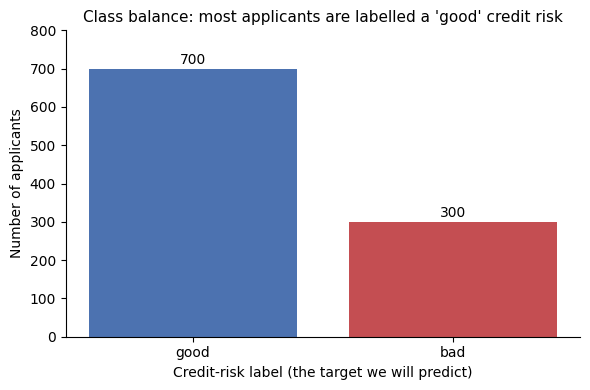

Caption: Of 1,000 applicants, 700 are labelled 'good' and 300 'bad' — a 70/30 imbalance. We must remember this when judging model performance later, because a model that simply guessed 'good' for everyone would already be 70% accurate.


In [3]:
# Count how many applicants are labelled 'good' and how many 'bad'.
counts = df["class"].value_counts()
print(counts)
print(f"\nShare 'good': {counts['good']/len(df):.0%}   |   Share 'bad': {counts['bad']/len(df):.0%}")

# --- Chart: class balance ---
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=["#4C72B0", "#C44E52"])
ax.set_title("Class balance: most applicants are labelled a 'good' credit risk", fontsize=11)
ax.set_xlabel("Credit-risk label (the target we will predict)")
ax.set_ylabel("Number of applicants")
ax.set_ylim(0, 800)
# Write the exact count on top of each bar.
for bar, value in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, value + 12, str(value), ha="center", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("Caption: Of 1,000 applicants, 700 are labelled 'good' and 300 'bad' — a 70/30 imbalance. "
      "We must remember this when judging model performance later, because a model that simply "
      "guessed 'good' for everyone would already be 70% accurate.")

In [4]:
# Separate the columns into numeric vs categorical (the target 'class' is set aside).
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(exclude="number").columns.drop("class").tolist() #catergorical columns except the last column "class"

print(f"{df.shape[0]} applicants, {df.shape[1]} columns "
      f"({len(num_cols)} numeric features, {len(cat_cols)} categorical features, 1 target).\n")

# Summary of the NUMERIC features: average, spread (std), range and percentiles.
print("===== NUMERIC FEATURES =====")
display(df[num_cols].describe().round(1).T)

# Summary of the CATEGORICAL features: how many categories, and the most common one.
print("\n===== CATEGORICAL FEATURES =====")
display(df[cat_cols].describe().T)

# A closer look at the main demographic field we will use in the fairness stage later.
print("\n===== personal_status (combines marital status and sex) =====")
print(df["personal_status"].value_counts())

1000 applicants, 21 columns (7 numeric features, 13 categorical features, 1 target).

===== NUMERIC FEATURES =====


,count,mean,std,min,25%,50%,75%,max
duration,1000.0,20.9,12.1,4.0,12.0,18.0,24.0,72.0
credit_amount,1000.0,3271.3,2822.7,250.0,1365.5,2319.5,3972.2,18424.0
installment_commitment,1000.0,3.0,1.1,1.0,2.0,3.0,4.0,4.0
residence_since,1000.0,2.8,1.1,1.0,2.0,3.0,4.0,4.0
age,1000.0,35.5,11.4,19.0,27.0,33.0,42.0,75.0
existing_credits,1000.0,1.4,0.6,1.0,1.0,1.0,2.0,4.0
num_dependents,1000.0,1.2,0.4,1.0,1.0,1.0,1.0,2.0



===== CATEGORICAL FEATURES =====


,count,unique,top,freq
checking_status,1000,4,no checking,394
credit_history,1000,5,existing paid,530
purpose,1000,10,radio/tv,280
savings_status,1000,5,<100,603
employment,1000,5,1<=X<4,339
personal_status,1000,4,male single,548
other_parties,1000,3,none,907
property_magnitude,1000,4,car,332
other_payment_plans,1000,3,none,814
housing,1000,3,own,713



===== personal_status (combines marital status and sex) =====
personal_status
male single           548
female div/dep/mar    310
male mar/wid           92
male div/sep           50
Name: count, dtype: int64


## Stage 2 — Preparing the data for modelling

Here we do the following:

1. **Define the target and features, and encode the target as numbers** — separate the answer we predict (`y`) from the inputs (`X`).
2. **Create a clean `sex` attribute** — we'll need it to test the model for bias later.
3. **Split the data into a training set and a test set** — so we can judge the model on data it has never seen.
4. **Build a preprocessing "recipe"** that turns text categories into numbers and puts all numbers on a comparable scale.


### Task 1 — Separate the target from the features, and encode it as a number

The model needs two things: **`X`**, the inputs (the 20 features), and **`y`**, the target (the `class` column). Since computers do arithmetic, we convert the target from text to a number:

- **`good` → 1** (the *favourable* outcome — the applicant is judged a safe bet, i.e. the kind who would be approved)
- **`bad` → 0**

We deliberately make **`good`** the "1" so that later fairness measures read naturally as **approval rates** — *"what fraction of group X does the model rate as good?"*.

In [5]:
# Separate the answer we want to predict (y) from the inputs (X).
y_raw = df["class"]                # the target column: 'good' / 'bad'
X = df.drop(columns=["class"])     # the 20 feature columns
#print(y_raw.value_counts()) #to see that unique value converts from good/bad to 1/0
# Models do arithmetic, not words, so encode the target as 0/1.
# We make 'good' the "1" (the FAVOURABLE outcome) so later fairness measures
# read naturally as approval rates across groups.
y = (y_raw == "good").astype(int)

print("Target encoding:  'good' -> 1 (favourable)   |   'bad' -> 0")
print(y.value_counts())
print("\nFeatures (X) shape:", X.shape)

Target encoding:  'good' -> 1 (favourable)   |   'bad' -> 0
class
1    700
0    300
Name: count, dtype: int64

Features (X) shape: (1000, 20)


### Task 2 — Create a clean "sex" attribute for the fairness analysis

Later we will ask: *does the model treat men and women differently?* To answer that, we need each applicant's sex as a simple `male`/`female` label. The dataset stores this inside `personal_status`, mixed together with marital status (e.g. `"male single"`, `"female div/dep/mar"`), so we extract just the sex part.



In [6]:
# Derive a clean SEX label from 'personal_status' for the fairness stage.
# In this dataset every male category starts with the word "male"
# the only female category is "female div/dep/mar". So we map accordingly.
sex = X["personal_status"].apply(lambda v: "male" if v.startswith("male") else "female")
sex.name = "sex" #previously it was "personal_status"

# Note: we do NOT remove 'personal_status' from X. The model may still use it.
# This 'sex' label is a separate copy, used only to GROUP applicants when we
# audit the model for bias later.
print("Sex distribution across all 1,000 applicants:")
print(sex.value_counts())

Sex distribution across all 1,000 applicants:
sex
male      690
female    310
Name: count, dtype: int64


### Task 3 — Split into a training set and a test set

We divide the 1,000 applicants into two groups:

- a **training set** (75% = 750 applicants) — used to *teach* the model, and
- a **test set** (25% = 250 applicants) — held back and used only to *judge* it on data it has never seen.

Here we ensure the following three things:
- **Keeping the mix (`stratify`):** because only 30% of applicants are "bad", a random split could leave very few "bad" cases in one half. Stratifying forces both halves to keep the same 70/30 good–bad mix.
- **Avoiding "leakage":** To avoid information from the test set sneak into preparation or training, which flatters the results. To prevent it, we split **first**, and any step that *learns* from the data (such as the scaling in Task 4) will be fitted on the **training set only**.
- **Reproducibility :** We will fix the random shuffle so the split is identical every time the notebook runs.

In [7]:
from sklearn.model_selection import train_test_split

# Split into training (75%) and test (25%) sets.
#   stratify=y    -> keep the same 70/30 good/bad mix in both halves
#   random_state  -> fix the shuffle so the split is identical every run
# We split the sex label alongside, so sex_test lines up with the test applicants.
X_train, X_test, y_train, y_test, sex_train, sex_test = train_test_split(
    X, y, sex, test_size=0.25, random_state=42, stratify=y
)

print(f"Training applicants: {X_train.shape[0]}")
print(f"Test applicants:     {X_test.shape[0]}")
print(f"\nShare 'good' kept balanced  ->  train: {y_train.mean():.0%}   test: {y_test.mean():.0%}")
print(f"\nSex breakdown in the TEST set (used later for the fairness check):")
print(sex_test.value_counts()) #check male and female in testing set
#print(sex_train.value_counts()) #check male and female in training set

Training applicants: 750
Test applicants:     250

Share 'good' kept balanced  ->  train: 70%   test: 70%

Sex breakdown in the TEST set (used later for the fairness check):
sex
male      173
female     77
Name: count, dtype: int64


In [8]:
# Look at the first 5 entries of the 'housing' column in X_train
X_train["housing"].head()

# Shows the count of unique categories in the housing column for X_train
X_train["housing"].value_counts()
#print(X_train.columns) #Checking labels of X_train

,count
housing,
own,545
rent,129
for free,76


### Task 4 — Build the preprocessing "recipe" (encode categories, scale numbers)

We use the following two transformations:

**1. One-hot encoding — turning categories into numbers.** For the columns like `housing` contains words (`own`, `rent`, `for free`).

**2. Scaling the numbers (`StandardScaler`).** We will rescale each numeric column to a common footing (centred near 0, with a comparable spread)

We bundle both steps into a single **`ColumnTransformer`**. It applies the right transformation to the right columns. Crucially, we **fit it on the training data only** (to avoid leakage).

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Which columns are numbers, and which are text categories?
numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()

# The preprocessing recipe:
#   - numbers      -> StandardScaler  (put them on a common scale)
#   - categories   -> OneHotEncoder   (turn each category into its own 0/1 column)
# handle_unknown="ignore" means: if an unseen category ever appears(during testing stage), don't crash.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

# Demonstrate the recipe. We FIT it on the TRAINING data only (never the test
# data) to avoid leakage, then see how many columns the data expands into.
X_train_prepared = preprocessor.fit_transform(X_train)
print(f"Numeric features: {len(numeric_features)}  |  Categorical features: {len(categorical_features)}")
print(f"Columns before preparation: {X_train.shape[1]}")
print(f"Columns after one-hot encoding: {X_train_prepared.shape[1]}")
print("\nNote: in Stage 3 we will NOT use this fitted object directly. Instead we plug the")
print("recipe into a Pipeline together with each model, so the preparation is re-fitted")
print("correctly for every model and the two models stay directly comparable.")

Numeric features: 7  |  Categorical features: 13
Columns before preparation: 20
Columns after one-hot encoding: 61

Note: in Stage 3 we will NOT use this fitted object directly. Instead we plug the
recipe into a Pipeline together with each model, so the preparation is re-fitted
correctly for every model and the two models stay directly comparable.


## Stage 3 — Building and evaluating the first model (logistic regression)

Now we build our **first credit-scoring model**: a **logistic regression**.

We will train it on the 750 training applicants, then measure its performance on the 250 **test** applicants it has never seen. We start with the headline **accuracy** number, then look past it by analysing its confusion matrix

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Bundle the preprocessing recipe + the model into ONE Pipeline.
# Calling .fit() makes the pipeline first prepare the data (fitting the recipe on
# the TRAINING set only), then train the logistic regression on the prepared data.
# max_iter=1000 just gives the solver enough steps to settle; random_state fixes
# any internal randomness so results are reproducible.
logreg = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42)),
])

logreg.fit(X_train, y_train)
print(f"Logistic regression trained on {X_train.shape[0]} applicants.")

Logistic regression trained on 750 applicants.


To check number of **iterations** completed

In [11]:
# 1. Grab the trained model step from your pipeline
trained_model = logreg.named_steps["model"]

# 2. Print the actual number of completed iterations
print(f"Actual iterations completed: {trained_model.n_iter_[0]}")

Actual iterations completed: 47


### Measuring accuracy — and why it can mislead



The code below reports the accuracy and compares it directly to the 70% baseline.

In [12]:
from sklearn.metrics import accuracy_score

# Make predictions on the held-out TEST set (data the model never saw in training).
y_pred = logreg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
baseline = y_test.mean()   # accuracy of a 'dumb' model that always guesses 'good'

print(f"Model accuracy on the test set: {accuracy:.1%}")
print(f"Baseline (always guess 'good'): {baseline:.1%}")
print(f"Improvement over the baseline:  {accuracy - baseline:+.1%}")

Model accuracy on the test set: 72.4%
Baseline (always guess 'good'): 70.0%
Improvement over the baseline:  +2.4%


### Looking past accuracy: the confusion matrix, precision, recall, and AUC

To see *what kind* of mistakes the model makes, we use a **confusion matrix** :

- **Actually good → predicted good**: correctly approved ✔
- **Actually good → predicted bad**: a creditworthy person wrongly denied ✗
- **Actually bad → predicted good**: a risky applicant wrongly approved — costly for the bank ✗
- **Actually bad → predicted bad**: correctly flagged as risky ✔

From this table we read three standard measures:
- **Precision** — of everyone the model *labelled* a given class, what fraction truly belong to it. *("When it says 'bad', how often is it right?")*
- **Recall** — of everyone who *truly* belongs to a class, what fraction the model *caught*. *("Of all the genuinely bad applicants, how many did it flag?")*
- **ROC-AUC** — a single number from 0.5 to 1.0 measuring how well the model *ranks* applicants by risk, regardless of where we set the approve/deny cut-off. **0.5 = no better than a coin flip; 1.0 = perfect.** It rewards giving riskier applicants lower "good" scores, even when the final yes/no labels are imperfect.

The code below prints all of these and draws the confusion matrix.

Detailed performance report for logistics regression:

              precision    recall  f1-score   support

     bad (0)       0.55      0.44      0.49        75
    good (1)       0.78      0.85      0.81       175

    accuracy                           0.72       250
   macro avg       0.66      0.64      0.65       250
weighted avg       0.71      0.72      0.71       250

ROC-AUC: 0.775

Of the 75 genuinely 'bad' applicants, the model flagged only 33 as bad (44%); 42 slipped through rated 'good'.


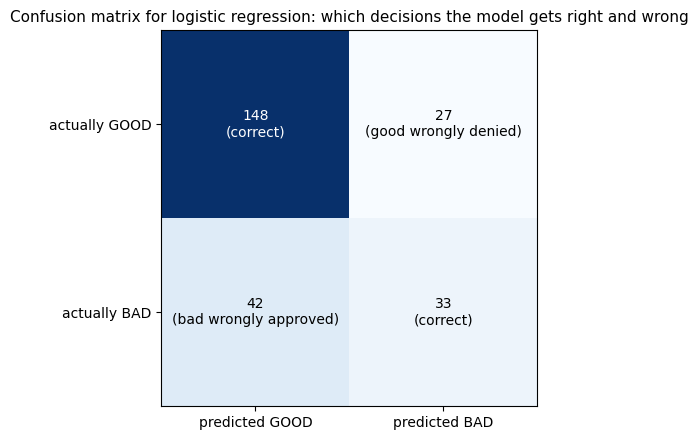

Caption: The model approves most good applicants (148) but catches fewer than half of the bad ones (33 of 75) — 42 risky applicants are wrongly rated 'good'. A single accuracy figure hides this lopsided pattern in the kinds of mistakes made.


In [13]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# The model's probability that each test applicant is 'good' (used for AUC).
y_proba = logreg.predict_proba(X_test)[:, 1]

# Count each of the four outcomes (good=1, bad=0).
g_as_g = int(((y_test == 1) & (y_pred == 1)).sum())   # good correctly approved
g_as_b = int(((y_test == 1) & (y_pred == 0)).sum())   # good wrongly denied
b_as_g = int(((y_test == 0) & (y_pred == 1)).sum())   # bad wrongly approved (risky)
b_as_b = int(((y_test == 0) & (y_pred == 0)).sum())   # bad correctly flagged

print("Detailed performance report for logistics regression:\n")
print(classification_report(y_test, y_pred, target_names=["bad (0)", "good (1)"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
print(f"\nOf the {int((y_test == 0).sum())} genuinely 'bad' applicants, the model flagged "
      f"only {b_as_b} as bad ({b_as_b/(y_test == 0).sum():.0%}); "
      f"{b_as_g} slipped through rated 'good'.")

# --- Chart: confusion matrix ---
cm = np.array([[g_as_g, g_as_b],
               [b_as_g, b_as_b]])
notes = [["correct", "good wrongly denied"],
         ["bad wrongly approved", "correct"]]
fig, ax = plt.subplots(figsize=(6, 4.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["predicted GOOD", "predicted BAD"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["actually GOOD", "actually BAD"])
ax.set_title("Confusion matrix for logistic regression: which decisions the model gets right and wrong", fontsize=11)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]}\n({notes[i][j]})", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=10)
plt.tight_layout()
plt.show()

print("Caption: The model approves most good applicants (148) but catches fewer than half "
      "of the bad ones (33 of 75) — 42 risky applicants are wrongly rated 'good'. "
      "A single accuracy figure hides this lopsided pattern in the kinds of mistakes made.")

## Stage 4 — Fairness / bias analysis (model 1: logistic regression)

We now check for **unfairness**. A model can be accurate overall yet still treat some groups of people systematically worse than others.

**The group we examine: sex (male vs female).** We use the `sex` label derived in Stage 2. We choose sex because it is a legally protected characteristic and the dataset lets us measure it — but the same method works for `age` or `foreign_worker`.



**How we structure it.** We package the whole audit into a reusable function, `fairness_report(...)`, so we can run the *identical* analysis on the random forest later and compare the two models.

In [14]:
def fairness_report(model, X_test, y_test, group, model_name):
    """Audit a fitted model for bias across the groups in `group` (e.g. sex).

    group: The demographic group we are checking for fairness (in this case, sex).
    model_name: A text label like "Logistic Regression" used for titles

    Prints a per-group table + headline gaps, draws a chart, and returns the
    table so results from different models can be compared later. Designed to be
    re-run UNCHANGED on any model (logistic regression, random forest, ...).
    """
    y_pred = pd.Series(model.predict(X_test), index=X_test.index)

    rows = []  # We will use this to store the fairness statistics for each group

    for g in sorted(group.unique()): #group.unique() finds all the unique categories (e.g., "male" and "female").
        #The for loop says: "Go through these unique categories one by one."
        mask = (group == g) #creates a True/False filter.For example, when looking at females, it flags all the female applicants as True and everyone else as False.
        yt, yp = y_test[mask], y_pred[mask]                 #yt:actual ansers, yp:model's guess
        rows.append(dict(
            group=g,
            n=int(mask.sum()),                              # number of people in this group
            approval_rate=(yp == 1).mean(),                 # selection rate
            truly_good_rate=(yt == 1).mean(),               # base rate (reality)
            TPR=(yp[yt == 1] == 1).mean(),                  # equal-opportunity rate
            FPR=(yp[yt == 0] == 1).mean(),
            accuracy=(yp == yt).mean(), # The overall percentage of guesses the model got right for this group.
        ))
    res = pd.DataFrame(rows).set_index("group")

    # --- Headline numbers (printed) ---
    print(f"===== Fairness report: {model_name} (grouped by sex) =====")
    print(res.round(3))
    f, m = res.loc["female"], res.loc["male"]
    print(f"\nApproval-rate gap (male - female): {m.approval_rate - f.approval_rate:+.1%}")
    print(f"Disparate-impact ratio (female / male): {f.approval_rate / m.approval_rate:.2f}"
          f"   (1.0 = parity; below 0.80 fails the 'four-fifths rule')")
    print(f"Equal-opportunity / TPR gap (male - female): {m.TPR - f.TPR:+.1%}"
          f"   (approval rate among the genuinely creditworthy)")

    # --- Chart: approval rate vs actual creditworthiness, per group ---
    groups = res.index.tolist()
    x = np.arange(len(groups)); w = 0.35 # w is width of the bars in the bar chart
    fig, ax = plt.subplots(figsize=(7, 4.5))
    b1 = ax.bar(x - w/2, res["approval_rate"], w, label="Model approval rate", color="#4C72B0")
    b2 = ax.bar(x + w/2, res["truly_good_rate"], w, label="Actually 'good' rate (reality)", color="#A9B4BD")
    ax.set_xticks(x); ax.set_xticklabels(groups)
    ax.set_ylabel("Share of group"); ax.set_ylim(0, 1)
    ax.set_title(f"{model_name}: who gets approved, by sex (vs. true creditworthiness)", fontsize=11)
    ax.legend()
    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{bar.get_height():.0%}", ha="center", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

    print(f"Caption: {model_name} approves {m.approval_rate:.0%} of men but only "
          f"{f.approval_rate:.0%} of women. Even among applicants who are genuinely creditworthy, "
          f"it approves {m.TPR:.0%} of men vs {f.TPR:.0%} of women — so equally qualified women "
          f"are approved less often. The approval gap is larger than the real difference in "
          f"creditworthiness between the groups.")
    return res

### Running the fairness check on the logistic regression

The cell below applies our `fairness_report` to the trained logistic regression, grouped by sex. It prints a per-group table (approval rate, the actual "truly good" rate, TPR, FPR and accuracy), the headline gaps, and draws a chart comparing each group's **model approval rate** against its **actual creditworthiness**.

===== Fairness report: Logistic Regression (grouped by sex) =====
          n  approval_rate  truly_good_rate    TPR   FPR  accuracy
group                                                             
female   77          0.688            0.675  0.769  0.52     0.675
male    173          0.792            0.711  0.878  0.58     0.746

Approval-rate gap (male - female): +10.4%
Disparate-impact ratio (female / male): 0.87   (1.0 = parity; below 0.80 fails the 'four-fifths rule')
Equal-opportunity / TPR gap (male - female): +10.9%   (approval rate among the genuinely creditworthy)


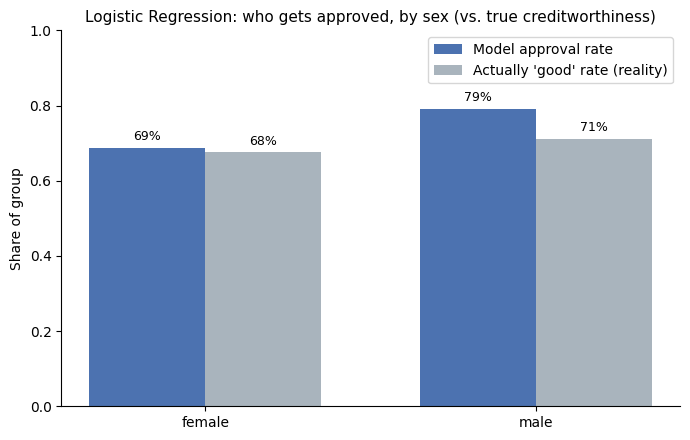

Caption: Logistic Regression approves 79% of men but only 69% of women. Even among applicants who are genuinely creditworthy, it approves 88% of men vs 77% of women — so equally qualified women are approved less often. The approval gap is larger than the real difference in creditworthiness between the groups.


In [15]:
# Run the identical fairness check on our logistic regression, grouped by sex.
# We store the result so we can place it side by side with the random forest later.
logreg_fairness = fairness_report(logreg, X_test, y_test, sex_test, "Logistic Regression")

## Stage 5 — Explainability with SHAP (model 1: logistic regression)

The second risk is **opacity**: AI models can make decisions that are hard to explain. So we now open up the model and ask: **which pieces of information actually drive its decisions?**

**The tool used: SHAP.** it measures how much each feature has pushed the prediction up or down compared with a typical applicant:
- **positive SHAP value → pushed the decision toward "good" (approve)**
- **negative SHAP value → pushed it toward "bad" (deny)**

**From one person to the whole model.** If we average the *size* of each feature's SHAP values (ignoring direction) across all applicants — written **mean |SHAP|** — we learn which features matter most *overall*. That is our measure of "what drives the model".


In [16]:
import shap
from matplotlib.patches import Patch

# The function below looks at the data, and if it is compressed (hasattr(a, "toarray")),
# it unpacks it into a normal dense grid. If it's already normal, it just leaves it alone.
def to_dense(a):
    """SHAP needs dense arrays; one-hot encoding can produce a sparse matrix."""
    return a.toarray() if hasattr(a, "toarray") else np.asarray(a)

def shap_explain(pipeline, X_train, X_test, model_name, top_n=15): # we look at top 15 features
    """Explain a fitted Pipeline (preprocessor + model) with SHAP.

    Works UNCHANGED for both the logistic regression and the random forest:
    shap.Explainer automatically chooses the right method for the model type.
    Prints the top drivers, shows where demographic features rank, draws a bar
    chart (demographic features highlighted), and returns the SHAP values +
    the importance ranking so the two models can be compared.
    """
    prep = pipeline.named_steps["prep"]
    model = pipeline.named_steps["model"]

    # Human-readable feature names after one-hot encoding (drop num__/cat__ prefixes).
    # When Scikit-Learn prepares data, it gives columns ugly, robotic names like cat__purpose_new car.
    # This line is basically a search-and-replace that chops off the ugly cat__ prefix so the final
    # chart has clean, human-readable labels like purpose_new car
    feat_names = [f.split("__", 1)[1] if "__" in f else f
                  for f in prep.get_feature_names_out()]

    # To make sure our data is in uncompressed format SHAP demands
    Xtr = pd.DataFrame(to_dense(prep.transform(X_train)), columns=feat_names)
    Xte = pd.DataFrame(to_dense(prep.transform(X_test)), columns=feat_names)

    # Use the whole training set as the "typical applicant" background (deterministic).
    masker = shap.maskers.Independent(Xtr, max_samples=Xtr.shape[0])
    explainer = shap.Explainer(model, masker, feature_names=feat_names)
    sv = explainer(Xte)

    vals = sv.values
    if vals.ndim == 3:          # tree classifiers return one set of values per class
        vals = vals[:, :, 1]    # keep the 'good' (positive) class

    # use np.abs becasue SHAP values can be positive (pushing toward approval) or
    # negative (pushing toward denial). Taking abs value and averaging it out gives
    # overall 'magnitude' of a feature's power
    mean_abs = pd.Series(np.abs(vals).mean(axis=0),
                         index=feat_names).sort_values(ascending=False)

    # Flag any feature derived from a personal / demographic attribute.
    demo_keys = ["personal_status", "age", "foreign_worker"]
    is_demo = lambda f: any(k in f for k in demo_keys)

    print(f"===== SHAP feature importance: {model_name} =====")
    print(f"Top {top_n} features driving the model's decisions (mean |SHAP|):\n")
    print(mean_abs.head(top_n).round(3))
    print(f"\nWhere the demographic features rank (out of {len(feat_names)} features):")
    for f in [c for c in mean_abs.index if is_demo(c)]:
        print(f"  rank {list(mean_abs.index).index(f) + 1:>3}:  {f}  (mean|SHAP|={mean_abs[f]:.3f})")
                                            #numbering in python starts from 0, so we add 1 in above code
    # --- Chart: top drivers, demographic features highlighted ---
    top = mean_abs.head(top_n)[::-1]   # reverse so the biggest is at the top
    colors = ["#C44E52" if is_demo(f) else "#4C72B0" for f in top.index]
    fig, ax = plt.subplots(figsize=(8, 5.5))
    ax.barh(top.index, top.values, color=colors)
    ax.set_xlabel("Average influence on the decision (mean |SHAP value|)")
    ax.set_title(f"{model_name}: features that most drive credit decisions", fontsize=11)
    ax.legend(handles=[Patch(color="#4C72B0", label="financial / other feature"),
                       Patch(color="#C44E52", label="demographic / personal feature")],
              loc="lower right")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

    print(f"Caption: For {model_name}, the strongest drivers are financial signals "
          f"(checking-account status, credit history, savings, loan size). But a "
          f"sex/marital-status feature and age also rank among the most influential "
          f"inputs (red bars) — personal attributes that are legally and ethically "
          f"sensitive in lending decisions.")
    return sv, mean_abs

### Running the SHAP explanation on the logistic regression

The cell below applies our `shap_explain` function to the trained logistic regression. It prints the top features driving the model's decisions, shows where the demographic features rank among all 61 inputs, and draws a bar chart with the **financial** features in blue and any **demographic/personal** features highlighted in red.

===== SHAP feature importance: Logistic Regression =====
Top 15 features driving the model's decisions (mean |SHAP|):

checking_status_no checking                      0.386
credit_history_critical/other existing credit    0.348
savings_status_<100                              0.318
checking_status_<0                               0.307
credit_amount                                    0.268
purpose_new car                                  0.249
installment_commitment                           0.248
purpose_used car                                 0.242
duration                                         0.235
property_magnitude_no known property             0.167
checking_status_0<=X<200                         0.164
other_payment_plans_none                         0.153
personal_status_male single                      0.150
employment_4<=X<7                                0.150
age                                              0.136
dtype: float64

Where the demographic features rank (out

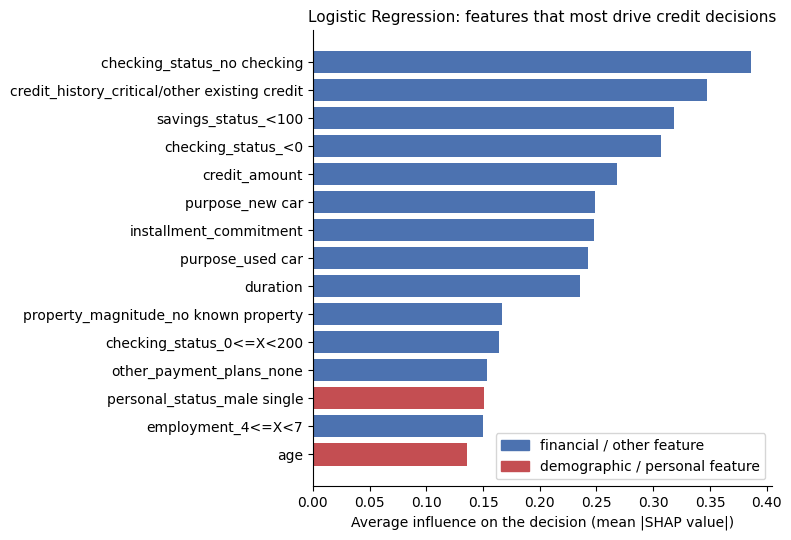

Caption: For Logistic Regression, the strongest drivers are financial signals (checking-account status, credit history, savings, loan size). But a sex/marital-status feature and age also rank among the most influential inputs (red bars) — personal attributes that are legally and ethically sensitive in lending decisions.


In [17]:
# Run the SHAP explanation on our logistic regression.
# We keep the returned values so we can compare against the random forest later.
logreg_shap_values, logreg_importance = shap_explain(
    logreg, X_train, X_test, "Logistic Regression")

## Stage 6 — The second model: random forest

To test whether the problems we found are specific to the logistic regression or more fundamental, we now build a **structurally different** model and put it through the *identical* analysis.


We run the same four steps, each with its own explanation — **build → accuracy → fairness → explainability** — and finish with a **side-by-side comparison**.

### Step 1 — Build and train the random forest

We reuse the *exact same* preprocessing recipe and train/test split, changing only the model. Bundling it in a Pipeline (just as before) keeps the two models directly comparable.

In [18]:
from sklearn.ensemble import RandomForestClassifier

# Same preprocessing recipe and same train/test split — only the model changes,
# which is what keeps the two models honestly comparable.
# n_estimators=300 -> 300 trees in the forest (default is 100); random_state=42 -> reproducible.
# keeping n_jobs=-1 so we could use every single CPU core available
rf = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
])

rf.fit(X_train, y_train)
print(f"Random forest (300 trees) trained on {X_train.shape[0]} applicants.")

Random forest (300 trees) trained on 750 applicants.


### Step 2 — Accuracy and error profile

We judge the random forest on the same held-out test applicants, using the same measures defined in Stage 3 (accuracy, the 70% baseline, ROC-AUC, and the confusion matrix).

Random forest accuracy: 76.8%   (baseline 'always good': 70.0%)
ROC-AUC: 0.799

Detailed performance report for Random Forest
              precision    recall  f1-score   support

     bad (0)       0.67      0.44      0.53        75
    good (1)       0.79      0.91      0.85       175

    accuracy                           0.77       250
   macro avg       0.73      0.67      0.69       250
weighted avg       0.76      0.77      0.75       250



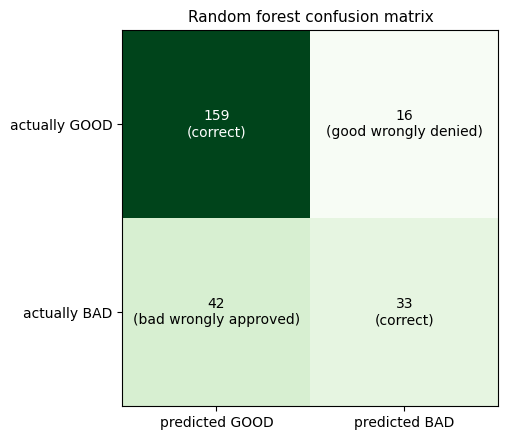

Caption: The random forest is more accurate overall (77%) and denies fewer good applicants (16 vs 27 for the logistic regression), but still catches only 33 of 75 bad applicants — the same blind spot as the linear model.


In [19]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, rf_pred)
print(f"Random forest accuracy: {rf_acc:.1%}   (baseline 'always good': {y_test.mean():.1%})")
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.3f}\n")
print("Detailed performance report for Random Forest")
print(classification_report(y_test, rf_pred, target_names=["bad (0)", "good (1)"]))


# Confusion-matrix counts (good=1, bad=0)
gg = int(((y_test == 1) & (rf_pred == 1)).sum())
gb = int(((y_test == 1) & (rf_pred == 0)).sum())
bg = int(((y_test == 0) & (rf_pred == 1)).sum())
bb = int(((y_test == 0) & (rf_pred == 0)).sum())

cm = np.array([[gg, gb], [bg, bb]])
notes = [["correct", "good wrongly denied"], ["bad wrongly approved", "correct"]]
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.imshow(cm, cmap="Greens")
ax.set_xticks([0, 1]); ax.set_xticklabels(["predicted GOOD", "predicted BAD"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["actually GOOD", "actually BAD"])
ax.set_title("Random forest confusion matrix", fontsize=11)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]}\n({notes[i][j]})", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=10)
plt.tight_layout(); plt.show()

print(f"Caption: The random forest is more accurate overall ({rf_acc:.0%}) and denies fewer "
      f"good applicants ({gb} vs 27 for the logistic regression), but still catches only {bb} "
      f"of {int((y_test == 0).sum())} bad applicants — the same blind spot as the linear model.")

### Step 3 — Fairness check (same function, grouped by sex)

We now call the very same `fairness_report` function on the random forest. The key question for our whole project: **is the same group (women) disadvantaged again, by a completely different kind of model?**

===== Fairness report: Random Forest (grouped by sex) =====
          n  approval_rate  truly_good_rate    TPR   FPR  accuracy
group                                                             
female   77          0.753            0.675  0.865  0.52      0.74
male    173          0.827            0.711  0.927  0.58      0.78

Approval-rate gap (male - female): +7.3%
Disparate-impact ratio (female / male): 0.91   (1.0 = parity; below 0.80 fails the 'four-fifths rule')
Equal-opportunity / TPR gap (male - female): +6.1%   (approval rate among the genuinely creditworthy)


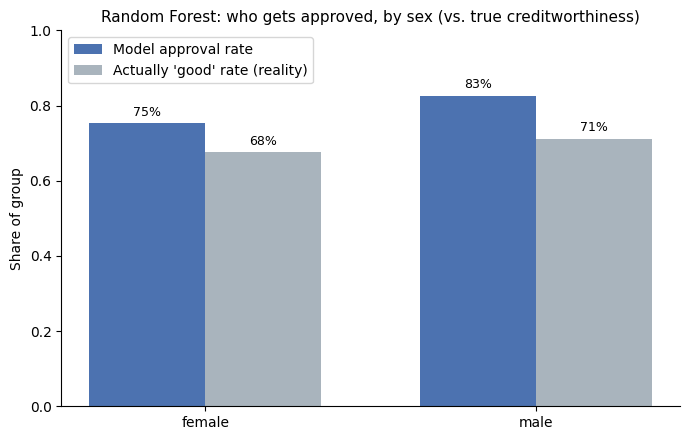

Caption: Random Forest approves 83% of men but only 75% of women. Even among applicants who are genuinely creditworthy, it approves 93% of men vs 87% of women — so equally qualified women are approved less often. The approval gap is larger than the real difference in creditworthiness between the groups.


In [20]:
# The very same fairness audit, now on the random forest. Stored for the comparison.
rf_fairness = fairness_report(rf, X_test, y_test, sex_test, "Random Forest")

### Step 4 — Explainability (same SHAP function)

We call the same `shap_explain` function on the random forest.

100%|===================| 499/500 [04:10<00:00]       

===== SHAP feature importance: Random Forest =====
Top 15 features driving the model's decisions (mean |SHAP|):

checking_status_no checking                      0.055
checking_status_<0                               0.041
duration                                         0.028
credit_history_critical/other existing credit    0.026
credit_amount                                    0.024
savings_status_<100                              0.020
age                                              0.018
purpose_new car                                  0.014
property_magnitude_no known property             0.014
other_payment_plans_none                         0.012
installment_commitment                           0.012
purpose_used car                                 0.011
checking_status_0<=X<200                         0.010
purpose_radio/tv                                 0.008
savings_status_no known savings                  0.008
dtype: float64

Where the demographic features rank (out of 61

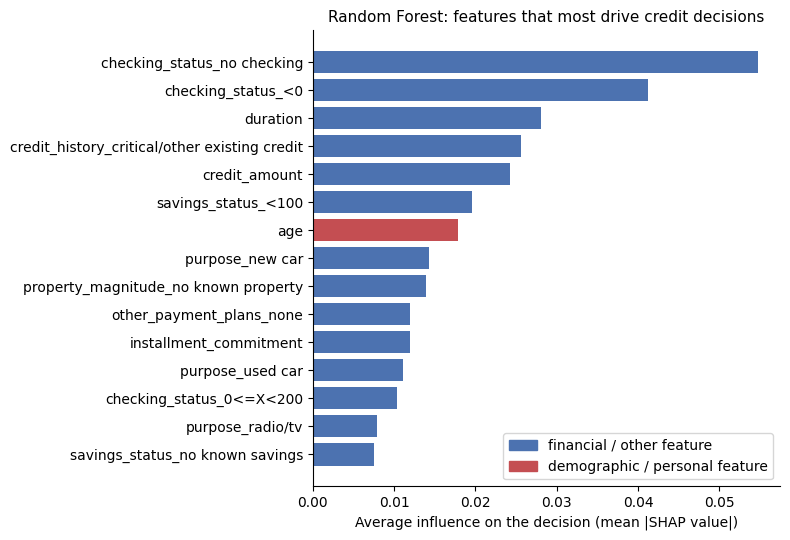

Caption: For Random Forest, the strongest drivers are financial signals (checking-account status, credit history, savings, loan size). But a sex/marital-status feature and age also rank among the most influential inputs (red bars) — personal attributes that are legally and ethically sensitive in lending decisions.


In [21]:
# NOTE: this cell can take a few MINUTES — computing exact SHAP values for a
# 300-tree forest is computationally heavy. A progress bar will appear; let it finish.
rf_shap_values, rf_importance = shap_explain(rf, X_train, X_test, "Random Forest")

### Step 5 — Side-by-side comparison

Finally we line up the two models' fairness numbers and approval rates so the pattern is visible at a glance. A model is "fairer" when its gaps are nearer **0** and its disparate-impact ratio is nearer **1.0**.

Fairness gaps, side by side (smaller gaps / ratio nearer 1.0 = fairer):

                        Logistic Regression  Random Forest
approval_female                       0.688          0.753
approval_male                         0.792          0.827
approval_gap (M-F)                    0.104          0.073
disparate_impact (F/M)                0.869          0.911
TPR_gap (M-F)                         0.109          0.061


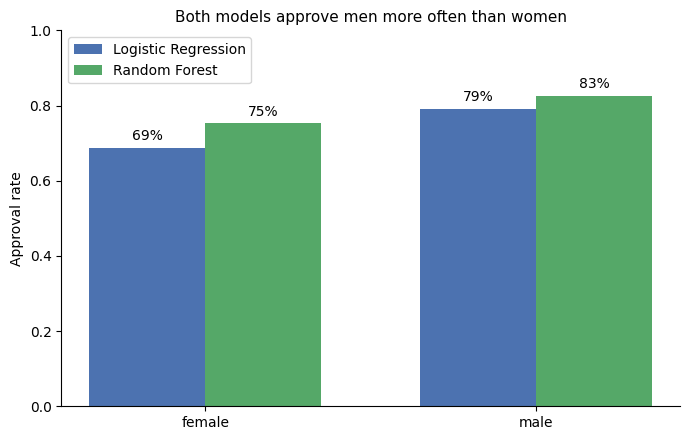

Caption: Across two structurally different models, women are approved less often than men. The random forest narrows the gap but does not close it — the same group is disadvantaged either way, pointing to bias rooted in the data, not one algorithm.


In [22]:
# --- Compare the two models side by side ---
def gaps(res):
    f, m = res.loc["female"], res.loc["male"]
    return pd.Series({
        "approval_female": f.approval_rate,
        "approval_male": m.approval_rate,
        "approval_gap (M-F)": m.approval_rate - f.approval_rate,
        "disparate_impact (F/M)": f.approval_rate / m.approval_rate,
        "TPR_gap (M-F)": m.TPR - f.TPR,
    })

comparison = pd.DataFrame({
    "Logistic Regression": gaps(logreg_fairness),
    "Random Forest": gaps(rf_fairness),
}).round(3)
print("Fairness gaps, side by side (smaller gaps / ratio nearer 1.0 = fairer):\n")
print(comparison)

# --- Chart: approval rate by sex, both models ---
labels = ["female", "male"]
x = np.arange(len(labels)); w = 0.35
fig, ax = plt.subplots(figsize=(7, 4.5))
b1 = ax.bar(x - w/2, [logreg_fairness.loc[g, "approval_rate"] for g in labels], w,
       label="Logistic Regression", color="#4C72B0")
b2 = ax.bar(x + w/2, [rf_fairness.loc[g, "approval_rate"] for g in labels], w,
       label="Random Forest", color="#55A868")
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0, 1)
ax.set_ylabel("Approval rate")
ax.set_title("Both models approve men more often than women", fontsize=11)
ax.legend(); ax.spines[["top", "right"]].set_visible(False)

# We loop through every single bar in both sets to add approval rate percentage on top of a bar
for bar in list(b1) + list(b2):
    height = bar.get_height()
    # Write the text in the center of the bar, bumped slightly up (+0.02)
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.02,
            f"{height:.0%}", ha="center", fontsize=10)


plt.tight_layout(); plt.show()

print("Caption: Across two structurally different models, women are approved less often than "
      "men. The random forest narrows the gap but does not close it — the same group is "
      "disadvantaged either way, pointing to bias rooted in the data, not one algorithm.")

## Stage 7 — Privacy: the third risk

The first two risks looked at **what the model decides** (fairness, Stage 4/6) and **why it decides** (explainability, Stage 5/6). This stage turns to a different question: **what does the model need to *know* about a person in order to decide at all — and what does relying on that data expose?**

Four ideas we will use:

- **Personal data** — any information tied to an identifiable individual. In a loan file this is almost everything: not just age or marital status, but income proxies, housing, employment, savings, and existing debts.
- **Sensitive (protected) attribute** — personal data that law and ethics say should *not* drive a lending decision: e.g. sex, marital status, age, or being a foreign worker.
- **Proxy variable** — a feature that is *not* itself protected but is statistically linked to one, so it can quietly **stand in** for it. Proxies are why privacy is hard: you cannot make a model "blind" to sex simply by deleting the sex column.
- **Re-identification** — reconstructing an individual, or a sensitive trait about them, by combining several otherwise-ordinary fields.



In [23]:
# Sort the 20 features into "directly sensitive" vs "financial / behavioural",
# then look up where the sensitive ones ranked among each model's SHAP drivers.

sensitive_keys = ["personal_status", "age", "foreign_worker"]
def is_sensitive(col):
    return any(k in col for k in sensitive_keys)

directly_sensitive   = [c for c in X.columns if is_sensitive(c)]
financial_behavioural = [c for c in X.columns if not is_sensitive(c)]

print(f"Total features the model sees: {X.shape[1]}")
print(f"  Directly sensitive (protected / demographic): {len(directly_sensitive)}")
print(f"    -> {directly_sensitive}")
print(f"  Financial & behavioural (NOT protected, but still personal data): {len(financial_behavioural)}")
print(f"    -> {financial_behavioural}\n")

# Best (lowest) SHAP rank each sensitive attribute reached, in each model.
# (After one-hot encoding a field like personal_status spans several columns;
#  we report the highest-ranking one. Lower number = more influential.)
n_feat = len(logreg_importance)
def best_rank(importance, key):
    ranks = [i + 1 for i, f in enumerate(importance.index) if key in f]
    return min(ranks) if ranks else None

rank_table = pd.DataFrame({
    f"Logistic Regression (of {n_feat})": [best_rank(logreg_importance, k) for k in sensitive_keys],
    f"Random Forest (of {n_feat})":       [best_rank(rf_importance, k) for k in sensitive_keys],
}, index=sensitive_keys)
rank_table.index.name = "sensitive attribute"
print("Where each sensitive attribute ranked among the model's SHAP drivers (1 = most influential):")
display(rank_table)
print("Takeaway: only 3 of 20 fields are 'protected', but the other 17 are still private personal "
      "data — and the protected three are not idle: SHAP ranks them among the influential inputs.")

Total features the model sees: 20
  Directly sensitive (protected / demographic): 3
    -> ['personal_status', 'age', 'foreign_worker']
  Financial & behavioural (NOT protected, but still personal data): 17
    -> ['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'other_parties', 'residence_since', 'property_magnitude', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone']

Where each sensitive attribute ranked among the model's SHAP drivers (1 = most influential):


,Logistic Regression (of 61),Random Forest (of 61)
sensitive attribute,,
personal_status,13,17
age,15,7
foreign_worker,32,53


Takeaway: only 3 of 20 fields are 'protected', but the other 17 are still private personal data — and the protected three are not idle: SHAP ranks them among the influential inputs.


### The proxy problem: does deleting the sensitive column solve this issue?



We set up a small experiment. We **delete the `personal_status` column entirely** — the only field that literally contains sex — and then train a fresh model whose only job is to **guess each applicant's sex from the remaining, ostensibly neutral features** (housing, employment, number of dependents, and so on). We measure it with **AUC**, the same 0.5-to-1.0 ranking score from Stage 3:

- If the model does **no better than a coin flip** (AUC ≈ 0.50), sex is genuinely hidden — deleting the column worked.
- If it does **better than chance** (AUC well above 0.50), then sex is *leaking* through **proxies** — and any credit model trained on the same data can absorb that leakage too, whether we intend it or not.

To see *which* "neutral" fields carry the leak, we then rank them by **permutation importance**: how much the sex-guessing accuracy drops when each feature's values are randomly shuffled. The features whose shuffling hurts most are the strongest proxies.

AUC guessing an applicant's SEX from non-sex features only: 0.655
(0.50 = no better than a coin flip; 1.00 = perfect. Sex was NEVER given to this model.)



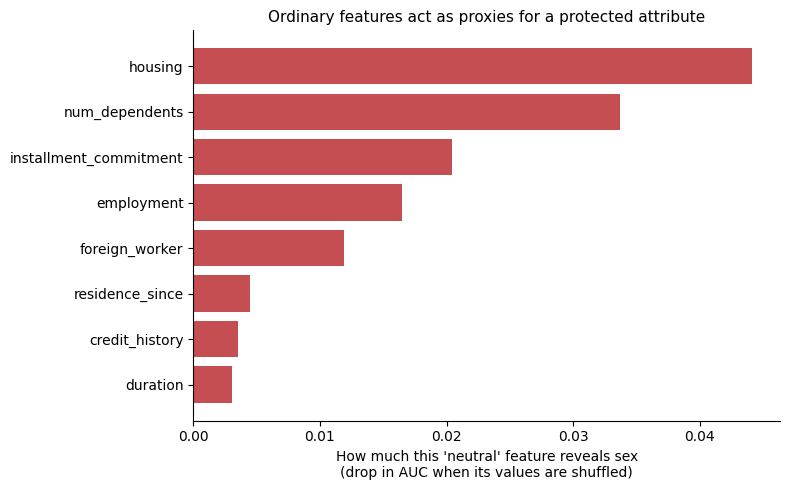

Caption: With the sex column deleted, a model still pins down an applicant's sex at AUC 0.65 — clearly above the 0.50 of random guessing — by leaning on everyday fields like housing, num_dependents, installment_commitment. Deleting a protected column does not erase the information: it survives as proxies, so privacy and fairness cannot be secured by 'blinding' the model alone.


In [24]:
# Experiment: can we identify an applicant's SEX from the other features alone,
# after deleting the one column that literally contains it?
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

# Target for THIS experiment = the protected attribute itself (female = 1).
sex_y_train = (sex_train == "female").astype(int)
sex_y_test  = (sex_test  == "female").astype(int)

# Drop ONLY 'personal_status' (the field that encodes sex); keep everything else.
proxy_cols = [c for c in X.columns if c != "personal_status"]
num_p = [c for c in proxy_cols if c in numeric_features]
cat_p = [c for c in proxy_cols if c in categorical_features]

proxy_prep = ColumnTransformer([
    ("num", StandardScaler(), num_p),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_p),
])
proxy_model = Pipeline([("prep", proxy_prep),
                        ("model", LogisticRegression(max_iter=1000, random_state=42))])
proxy_model.fit(X_train[proxy_cols], sex_y_train)

# How well can it guess sex on held-out applicants it never saw?
proxy_auc = roc_auc_score(sex_y_test, proxy_model.predict_proba(X_test[proxy_cols])[:, 1])
print(f"AUC guessing an applicant's SEX from non-sex features only: {proxy_auc:.3f}")
print("(0.50 = no better than a coin flip; 1.00 = perfect. Sex was NEVER given to this model.)\n")

# Which 'neutral' features leak the most? Permutation importance = how much the
# AUC drops when each feature's values are randomly shuffled (bigger = stronger proxy).
pi = permutation_importance(proxy_model, X_test[proxy_cols], sex_y_test,
                            scoring="roc_auc", n_repeats=10, random_state=42)
leak = pd.Series(pi.importances_mean, index=proxy_cols).sort_values(ascending=False).head(8)

top = leak[::-1]   # smallest at bottom so the biggest sits on top
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index, top.values, color="#C44E52")
ax.set_xlabel("How much this 'neutral' feature reveals sex\n(drop in AUC when its values are shuffled)")
ax.set_title("Ordinary features act as proxies for a protected attribute", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

leakers = ", ".join(top.index[::-1][:3])
print(f"Caption: With the sex column deleted, a model still pins down an applicant's sex at "
      f"AUC {proxy_auc:.2f} — clearly above the 0.50 of random guessing — by leaning on everyday "
      f"fields like {leakers}. Deleting a protected column does not erase the information: it "
      f"survives as proxies, so privacy and fairness cannot be secured by 'blinding' the model alone.")